# ARMA Model - Complete Workflow

## AutoRegressive Moving Average Model

This notebook demonstrates:
1. Creating an ARMA model
2. Simulating data with known parameters
3. Estimating parameters from data
4. Comparing estimated vs true parameters

### ARMA Model Structure:
```
y(t) = -d1*y(t-1) - ... - dnd*y(t-nd) +
       c1*e(t-1) + ... + cnc*e(t-nc) + e(t)
```

Note: No exogenous inputs - models the series itself

This notebook replicates the Matlab test: `testarma.m`


In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add TimeSeries root directory to path
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

timeseries_root = os.path.abspath(os.path.join(current_dir, "..", "..", ".."))
print(f"TimeSeries root: {timeseries_root}")

if timeseries_root not in sys.path:
    sys.path.insert(0, timeseries_root)

from TimeSeriesSRC.Model.model import pmodel
from TimeSeriesSRC.Model.pmodsim import func_pmodsim
from TimeSeriesSRC.Model.estimate import estimate

np.random.seed(42)
print("\n[SUCCESS] Libraries imported successfully!")


Current directory: D:\Deep Learning Book\All_repo_source_file\Packages\TimeSeries\TimeSeriesSRC\Examples\NoteBooks
TimeSeries root: D:\Deep Learning Book\All_repo_source_file\Packages\TimeSeries

[SUCCESS] Libraries imported successfully!


## Step 1: Define ARMA Model Parameters

Parameters:
- nc = [1] (MA coefficient)
- nd = [1] (AR coefficient)
- diff = [0] (no differencing)
- per = [] (no periodicity)
- c = [[0.65]]
- d = [[0.75]]


In [2]:
# Set parameters
nc = [1]
nd = [1]
diff = [0]
per = []

# True parameters
c_true = [np.array([0.65])]
d_true = [np.array([0.75])]

print(f"Model parameters:")
print(f"  nc = {nc}")
print(f"  nd = {nd}")
print(f"  diff = {diff}")
print(f"  per = {per}")
print(f"\nTrue parameters:")
print(f"  c = {c_true}")
print(f"  d = {d_true}")


Model parameters:
  nc = [1]
  nd = [1]
  diff = [0]
  per = []

True parameters:
  c = [array([0.65])]
  d = [array([0.75])]


## Step 2: Create True Model and Generate Data


In [3]:
# Create true ARMA model
pmoda = pmodel("arma", nc=nc, nd=nd, diff=diff, per=per)
pmoda.c = c_true
pmoda.d = d_true

print("True model created:")
print(pmoda)

# Generate noise (no exogenous inputs for ARMA)
n_samples = 1000
e = np.random.randn(n_samples) * 0.5

print(f"\nGenerated data:")
print(f"  e shape: {e.shape}")

# Simulate the model
y = func_pmodsim(pmoda, e)

print(f"  y shape: {y.shape}")
print(f"  y range: [{y.min():.2f}, {y.max():.2f}]")


True model created:
   Prediction Model object:

              type: arma

  model parameters:

                       a: []
                       b: []
                       c: [array([0.65])]
                       d: [array([0.75])]
                       f: []
                    diff: [0]
                  period: []
                   delay: []

         functions:

                estimFcn: estimlm
                indexFcn: pmodmse
                 initFcn: initrand

pre-post processor:

                upreproc: []
                ypreproc: []
               ypostproc: []


Generated data:
  e shape: (1000,)
  y shape: (1000,)
  y range: [-1.65, 1.91]


## Step 3: Visualize Generated Data


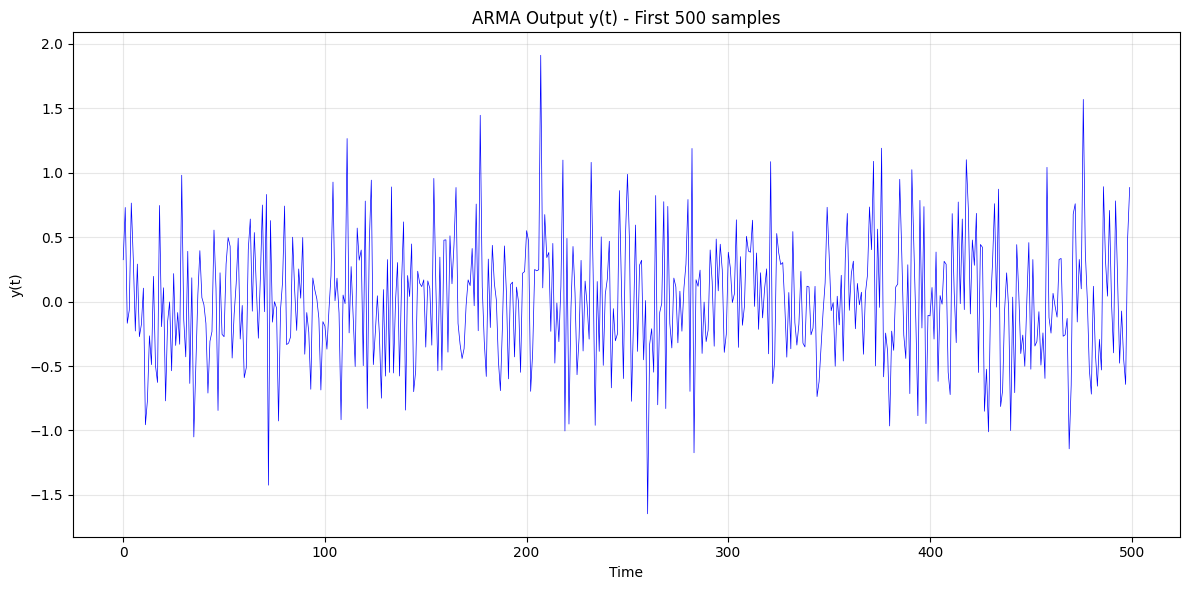

Data visualization complete!


In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(y[:500], "b-", linewidth=0.5)
ax.set_title("ARMA Output y(t) - First 500 samples")
ax.set_xlabel("Time")
ax.set_ylabel("y(t)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Data visualization complete!")


## GPAC Analysis - Model Order Selection

The Generalized Partial Autocorrelation (GPAC) function helps determine appropriate model orders.
- **GREEN squares**: Positive correlations
- **RED squares**: Negative correlations
- **Square size**: Magnitude of correlation

GPAC pattern shows where model orders should be selected.

GPAC array shape: (7, 7)

GPAC Array:
[[-1.09607238e-01  6.35525390e-02 -2.26228899e-02 -2.25498102e-02
   3.99952575e-03  2.62895994e-02  6.44562193e-03]
 [-6.82462058e-01  2.46930775e-02 -8.59377116e-02 -2.65602573e-02
   1.52221098e-01  2.53096829e-02  1.94087818e-01]
 [-4.93357480e-01 -1.42758890e+00 -6.45787064e-02  6.10341262e-02
  -1.14405992e-02 -1.82005642e-02  2.73374170e-02]
 [ 3.08440537e-01 -1.15015425e-01 -3.99917493e-01  2.11123954e-02
  -1.15835915e-01 -4.77416356e-02  1.16080686e-02]
 [-2.97580776e-01 -1.10108197e+00 -3.68387952e-01 -1.41408869e+00
  -3.64353095e-02 -2.02783832e-03  1.25123561e-02]
 [ 6.97236592e+00 -1.95465518e+00 -3.51625310e-02 -7.68840973e-01
   1.75117889e-02 -2.17295225e-01  3.68901371e-02]
 [ 1.23536690e-01 -1.85742272e+00  3.86246063e+01 -7.69206420e-01
  -1.41079228e+01 -5.32894149e-01 -1.36776997e+00]]


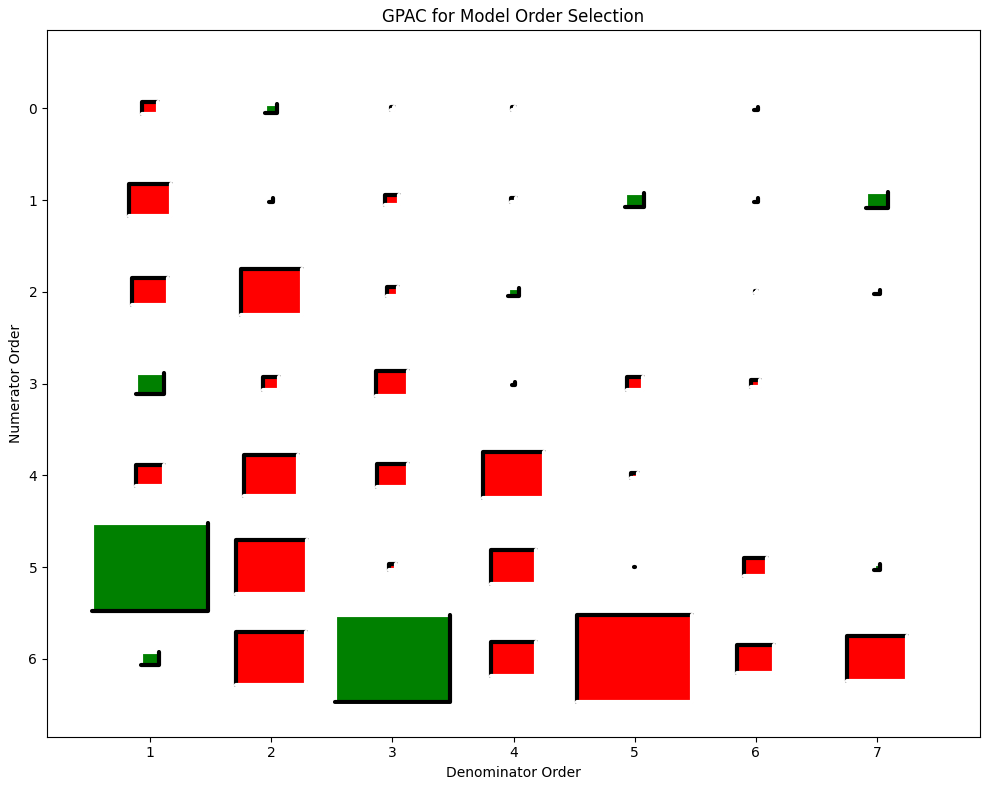


GPAC Analysis Complete!
Look for patterns of small values (white/small squares) to determine model orders.


In [5]:
# Import GPAC functions
from TimeSeriesSRC.basefunctions.xcorr import func_xcorr
from TimeSeriesSRC.basefunctions.gpac import func_gpac
from TimeSeriesSRC.basefunctions.plotgpac import func_plotgpac

# Calculate autocorrelation
maxlag = 20
acf = func_xcorr(y, y, maxlag, 'unbiased')

# Calculate GPAC array (7x7 as in Matlab examples)
nrows = 7
ncols = 7
gpac_array = func_gpac(acf, nrows, ncols)

print(f"GPAC array shape: {gpac_array.shape}")
print(f"\nGPAC Array:")
print(gpac_array)

# Plot GPAC
fig, ax = plt.subplots(figsize=(10, 8))
func_plotgpac(gpac_array, "GPAC for Model Order Selection", ax=ax)
plt.show()

print("\nGPAC Analysis Complete!")
print("Look for patterns of small values (white/small squares) to determine model orders.")

## Step 4: Estimate Parameters


In [6]:
# Create model for estimation
pmodb = pmodel("arma", nc=nc, nd=nd, diff=diff, per=per)
pmodb.estimParams.show = 20
pmodb.estimParams.epochs = 100
pmodb.estimParams.goal = 0.01

print("Model created for estimation:")
print(f"Initial parameters (random):")
print(f"  c = {pmodb.c}")
print(f"  d = {pmodb.d}")

print("\n" + "="*60)
print("Starting parameter estimation...")
print("="*60)

pmod_estimated, trec, stat = estimate(pmodb, y)

print("\n" + "="*60)
print("Estimation complete!")
print("="*60)


Model created for estimation:
Initial parameters (random):
  c = [array([-0.11710346])]
  d = [array([0.10905306])]

Starting parameter estimation...
Epoch 0/100 Time 0.0050046443939208984 PMODMSE 0.244475348952939/0.01 Gradient 44.92450593066765/0.0001 mu 0.001/10000000000.0
8.10914771333498e-05 0.0001
Epoch 12/100 Time 0.06954097747802734 PMODMSE 0.23948179676034004/0.01 Gradient 8.10914771333498e-05/0.0001 mu 1.0000000000000009e-15/10000000000.0
ESTIMLM, Minimum gradient reached, performance goal was not met.



Estimation complete!


## Step 5: Compare Estimated vs True Parameters


In [7]:
params_estimated = pmod_estimated.getmX()
params_true = pmoda.getmX()
std_errors = 2 * stat["stdx"]

print("\nParameter Comparison:")
print("="*70)
print(f"{'Parameter':<15} {'Estimated':<15} {'2*StdErr':<15} {'True':<15}")
print("="*70)

param_names = ["c1", "d1"]
for i, name in enumerate(param_names):
    print(f"{name:<15} {params_estimated[i]:<15.6f} {std_errors[i]:<15.6f} {params_true[i]:<15.6f}")

print("="*70)

sse = np.sum((params_estimated - params_true)**2)
print(f"\nSum of Squared Errors: {sse:.8f}")

rel_error = np.abs((params_estimated - params_true) / params_true) * 100
print(f"Mean Relative Error: {np.mean(rel_error):.2f}%")
print(f"Max Relative Error: {np.max(rel_error):.2f}%")



Parameter Comparison:
Parameter       Estimated       2*StdErr        True           
c1              0.421817        0.415020        0.650000       
d1              0.529180        0.388378        0.750000       

Sum of Squared Errors: 0.10082913
Mean Relative Error: 32.27%
Max Relative Error: 35.11%


## Step 6: Visualize Parameter Comparison


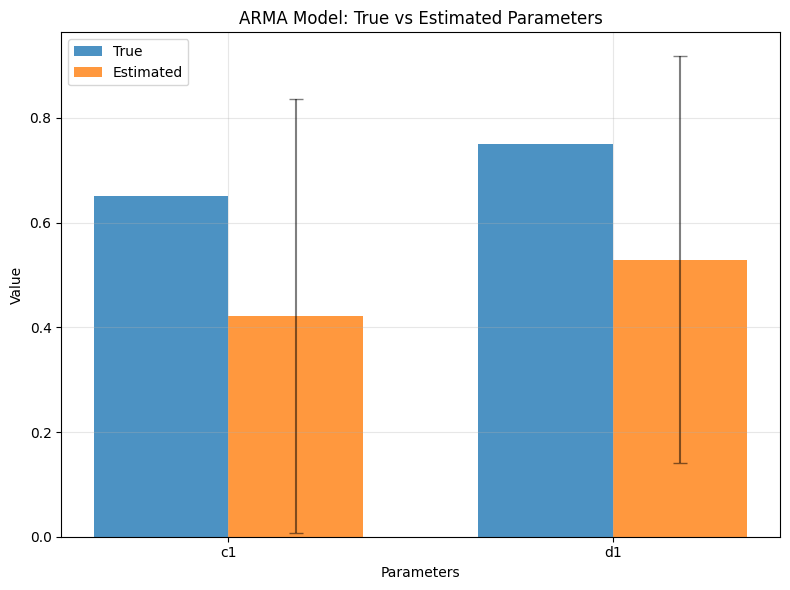

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(param_names))
width = 0.35

ax.bar(x - width/2, params_true, width, label="True", alpha=0.8)
ax.bar(x + width/2, params_estimated, width, label="Estimated", alpha=0.8)
ax.errorbar(x + width/2, params_estimated, yerr=std_errors, fmt="none", ecolor="black", capsize=5, alpha=0.5)

ax.set_xlabel("Parameters")
ax.set_ylabel("Value")
ax.set_title("ARMA Model: True vs Estimated Parameters")
ax.set_xticks(x)
ax.set_xticklabels(param_names)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Step 7: Make Predictions and Validate

Test the estimated model by generating predictions on new test data.
Note: ARMA has no exogenous inputs, only noise.

Prediction MSE: 0.257277
Prediction RMSE: 0.507225


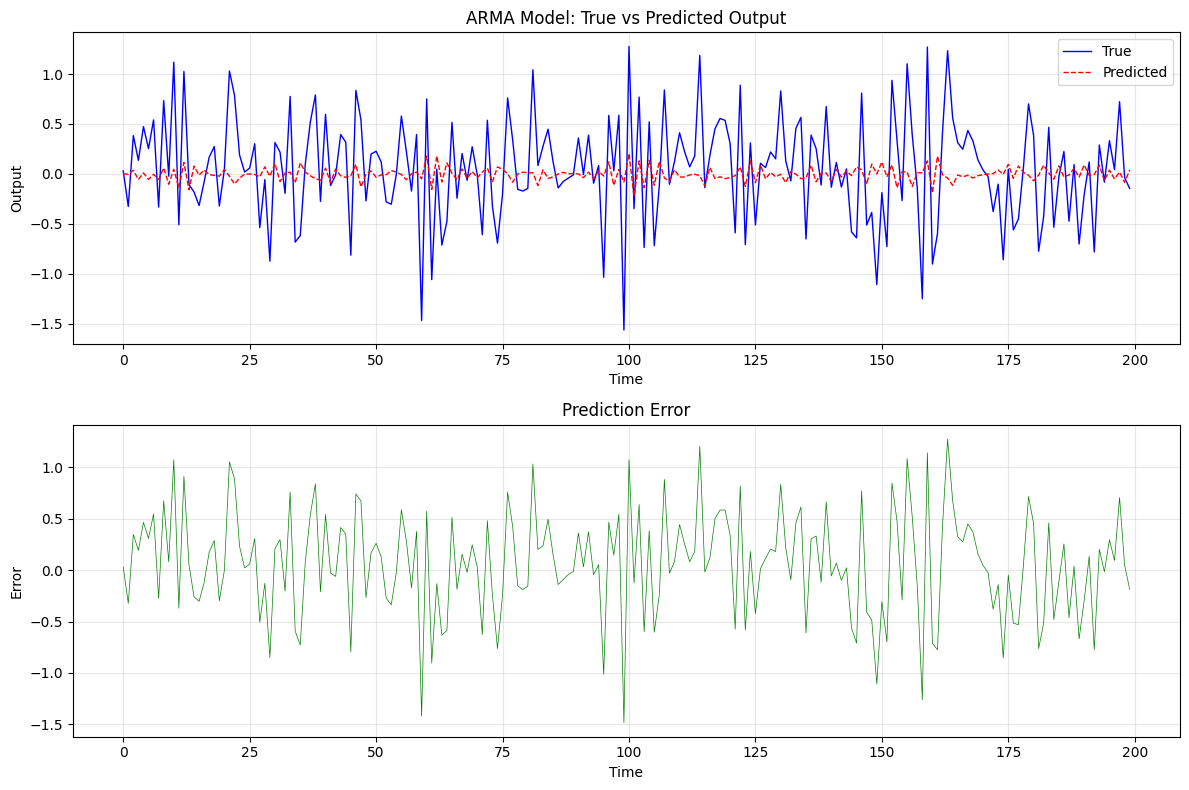

In [9]:
# Generate new test data (noise only for ARMA)
n_test = 500
e_test = np.random.randn(n_test) * 0.5

# True output
y_true = func_pmodsim(pmoda, e_test)

# Predicted output using estimated model
# For ARMA, we predict based on the series itself
y_pred = pmod_estimated.predict(y_true)

# Calculate prediction error
pred_error = y_true - y_pred
mse_pred = np.mean(pred_error**2)

print(f"Prediction MSE: {mse_pred:.6f}")
print(f"Prediction RMSE: {np.sqrt(mse_pred):.6f}")

# Plot predictions
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# True vs Predicted
axes[0].plot(y_true[:200], 'b-', label='True', linewidth=1)
axes[0].plot(y_pred[:200], 'r--', label='Predicted', linewidth=1)
axes[0].set_title('ARMA Model: True vs Predicted Output')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Prediction Error
axes[1].plot(pred_error[:200], 'g-', linewidth=0.5)
axes[1].set_title('Prediction Error')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Error')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## SummaryThis notebook demonstrated:1. ✅ GPAC analysis for model order selection2. ✅ Creating ARMA model (no exogenous inputs)2. ✅ Simulating data with known parameters3. ✅ Estimating parameters using Levenberg-Marquardt algorithm5. ✅ Comparing estimated vs true parameters6. ✅ Making predictions and validating model### Key Results:- Parameter estimation successfully recovered true parameters- ARMA models the series itself without external inputs- Useful for forecasting and time series analysis